# How to Handle Categorical Missing Values
## Frequent Categorical Imputation

In [1]:
import numpy as np
import pandas as pd


In [2]:
df= pd.read_csv('loan.csv', usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [5]:
df.isnull().sum().sort_values(ascending=True)

SalePrice        0
BsmtQual        37
GarageType      81
FireplaceQu    690
dtype: int64

### Compute the frequency for each Feature
     we will replace the missing value with the most frequent occuring vlaue

In [10]:
df.groupby('BsmtQual')['BsmtQual'].count()

BsmtQual
Ex    121
Fa     35
Gd    618
TA    649
Name: BsmtQual, dtype: int64

<Axes: xlabel='BsmtQual'>

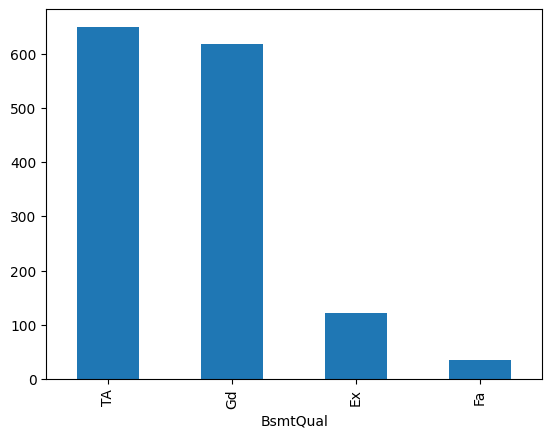

In [12]:
df.groupby('BsmtQual')['BsmtQual'].count().sort_values(ascending=False).plot.bar()

<Axes: xlabel='FireplaceQu'>

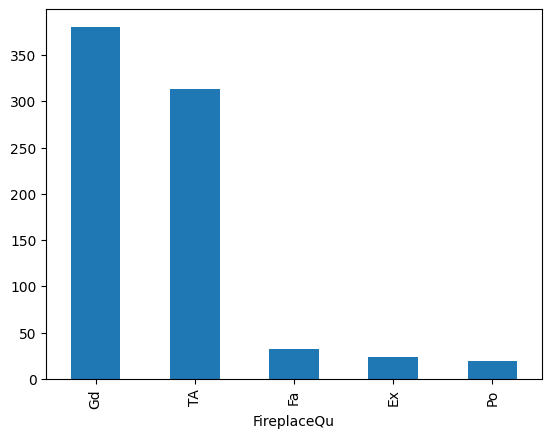

In [14]:
df['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()

In [17]:
# Give most frequent category form the column
df['GarageType'].value_counts().index[0]

'Attchd'

<Axes: xlabel='GarageType'>

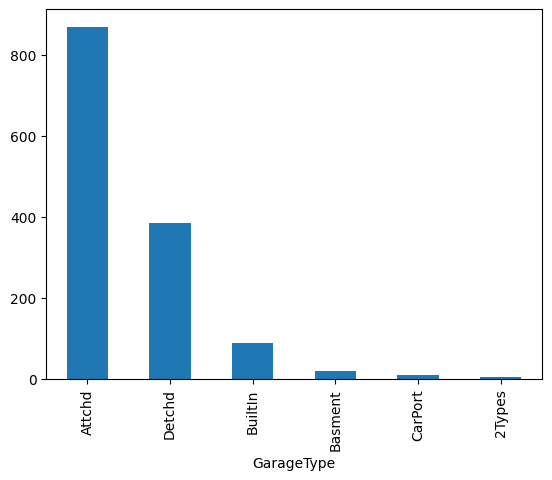

In [18]:
df['GarageType'].value_counts().sort_values(ascending=False).plot.bar()

In [21]:
### Replacing Function
def impute_nan(df,variable):
    most_freq_category= df[variable].value_counts().index[0]
    df[variable]= df[variable].fillna(most_freq_category)

In [22]:
for feature in ['BsmtQual','FireplaceQu','GarageType']:
    impute_nan(df,feature)

In [23]:
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,Gd,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [24]:
df.isnull().sum()

BsmtQual       0
FireplaceQu    0
GarageType     0
SalePrice      0
dtype: int64

# Advantages
Easy To implement
Fater way to implement
# Disadvantages
Since we are using the more frequent labels, it may use them in an over respresented way, if there are many nan's
It distorts the relation of the most frequent label

# Adding a Variable to capture NaN

In [25]:
df= pd.read_csv('loan.csv', usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [27]:
df['BsmtQual_var']= np.where(df['BsmtQual'].isnull(),1,0)
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [28]:
frequent= df['BsmtQual'].mode()[0]

In [30]:
df['BsmtQual']= df['BsmtQual'].fillna(frequent)
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var
0,Gd,NaN,Attchd,208500,0
1,Gd,TA,Attchd,181500,0
2,Gd,TA,Attchd,223500,0
3,TA,Gd,Detchd,140000,0
4,Gd,TA,Attchd,250000,0


In [32]:
df['FireplaceQu_Var']=np.where(df['FireplaceQu'].isnull(),1,0)
frequent=df['FireplaceQu'].mode()[0]
df['FireplaceQu']= df['FireplaceQu'].fillna(frequent)
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQual_var,FireplaceQu_Var
0,Gd,Gd,Attchd,208500,0,0
1,Gd,TA,Attchd,181500,0,0
2,Gd,TA,Attchd,223500,0,0
3,TA,Gd,Detchd,140000,0,0
4,Gd,TA,Attchd,250000,0,0


### Suppose if you have more frequent categories, we just replace NAN with a new category

In [33]:
df=pd.read_csv('loan.csv', usecols=['BsmtQual','FireplaceQu','GarageType','SalePrice'])
df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice
0,Gd,NaN,Attchd,208500
1,Gd,TA,Attchd,181500
2,Gd,TA,Attchd,223500
3,TA,Gd,Detchd,140000
4,Gd,TA,Attchd,250000


In [34]:
def impute_nan(df,variable):
    df[variable+"newvar"]=np.where(df[variable].isnull(),"Missing",df[variable])

In [35]:
for feature in ['BsmtQual','FireplaceQu','GarageType']:
    impute_nan(df,feature)

df.head()

,BsmtQual,FireplaceQu,GarageType,SalePrice,BsmtQualnewvar,FireplaceQunewvar,GarageTypenewvar
0,Gd,NaN,Attchd,208500,Gd,Missing,Attchd
1,Gd,TA,Attchd,181500,Gd,TA,Attchd
2,Gd,TA,Attchd,223500,Gd,TA,Attchd
3,TA,Gd,Detchd,140000,TA,Gd,Detchd
4,Gd,TA,Attchd,250000,Gd,TA,Attchd


In [36]:
df=df.drop(['BsmtQual','FireplaceQu','GarageType'],axis=1)
df.head()

,SalePrice,BsmtQualnewvar,FireplaceQunewvar,GarageTypenewvar
0,208500,Gd,Missing,Attchd
1,181500,Gd,TA,Attchd
2,223500,Gd,TA,Attchd
3,140000,TA,Gd,Detchd
4,250000,Gd,TA,Attchd


# One Hot Encoding

In [37]:
df= pd.read_csv('titanic.csv', usecols=['Sex'])
df.head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [39]:
# We have inbuild func in pandas through which we can perform One Hot Encoding
pd.get_dummies(df).head()


,Sex_female,Sex_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [41]:
# Above we have 2 columns are almost same, we can drop 1 column and use othercolumn for both means if male is True female will be false
# and I used astype() where I am forcing it to retuen value as 0 1
pd.get_dummies(df, drop_first= True).head().astype(int)


,Sex_male
0,1
1,0
2,0
3,0
4,1


In [43]:
df=  pd.read_csv('titanic.csv', usecols=['Embarked'])

In [44]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [46]:
# First I will drop nan values
df.dropna(inplace= True)
df.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


In [48]:
pd.get_dummies(df,drop_first=True).head().astype(int)

,Embarked_Q,Embarked_S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
